# 📈 Sales Prediction with Machine Learning
### End-to-End Regression Project

**Objective:** Predict product **Sales** (in thousands of units) based on advertising spend across three media channels — **TV**, **Radio**, and **Newspaper**.

**Dataset:** 200 records — classic Advertising dataset with 3 features and 1 continuous target.

---
**Pipeline Overview:**
1. Import Libraries  
2. Load & Explore the Data  
3. Exploratory Data Analysis (EDA)  
4. Feature Engineering  
5. Model Building (7 Algorithms)  
6. Model Comparison & Evaluation  
7. Hyperparameter Tuning  
8. Feature Importance & Coefficients  
9. Sales Forecasting on New Budgets

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries loaded!')

✅ All libraries loaded!


## 2. Load & Explore the Data

In [2]:
df = pd.read_csv('Advertising.csv', index_col=0)

print(f'Shape: {df.shape}')
df.head(10)

Shape: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [4]:
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


In [5]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')
print('\n✅ No missing values or duplicates — clean dataset!')

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicates: 0

✅ No missing values or duplicates — clean dataset!


## 3. Exploratory Data Analysis (EDA)

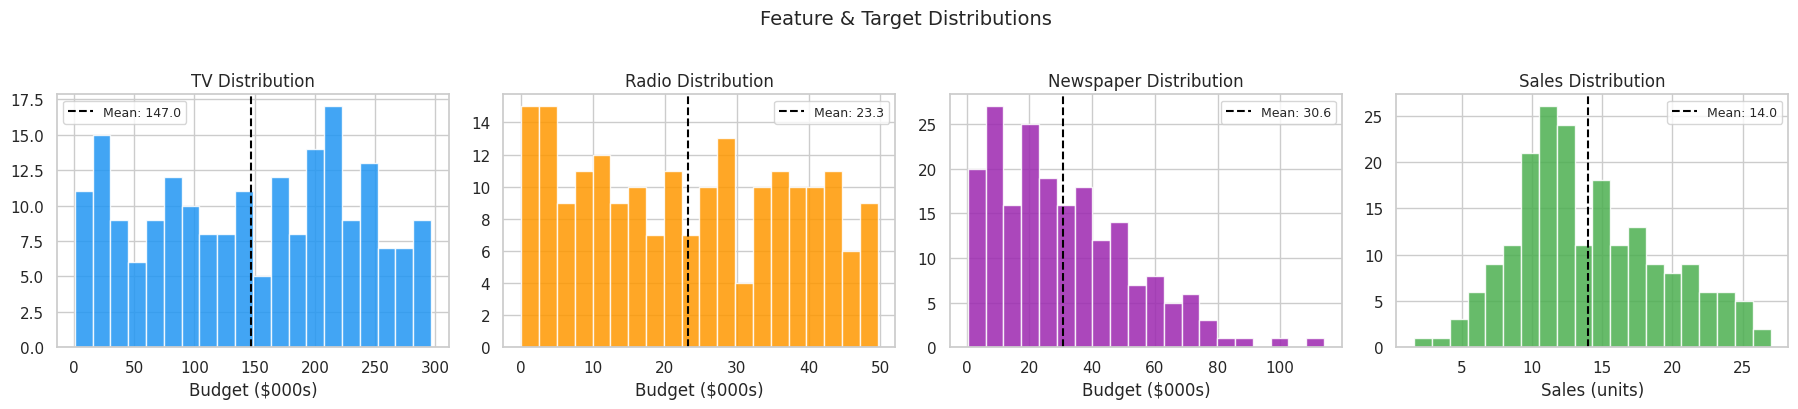

In [6]:
# Budget distribution across channels
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

for ax, col, color in zip(axes, ['TV', 'Radio', 'Newspaper', 'Sales'], colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', lw=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('Budget ($000s)' if col != 'Sales' else 'Sales (units)')
    ax.legend(fontsize=9)

plt.suptitle('Feature & Target Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

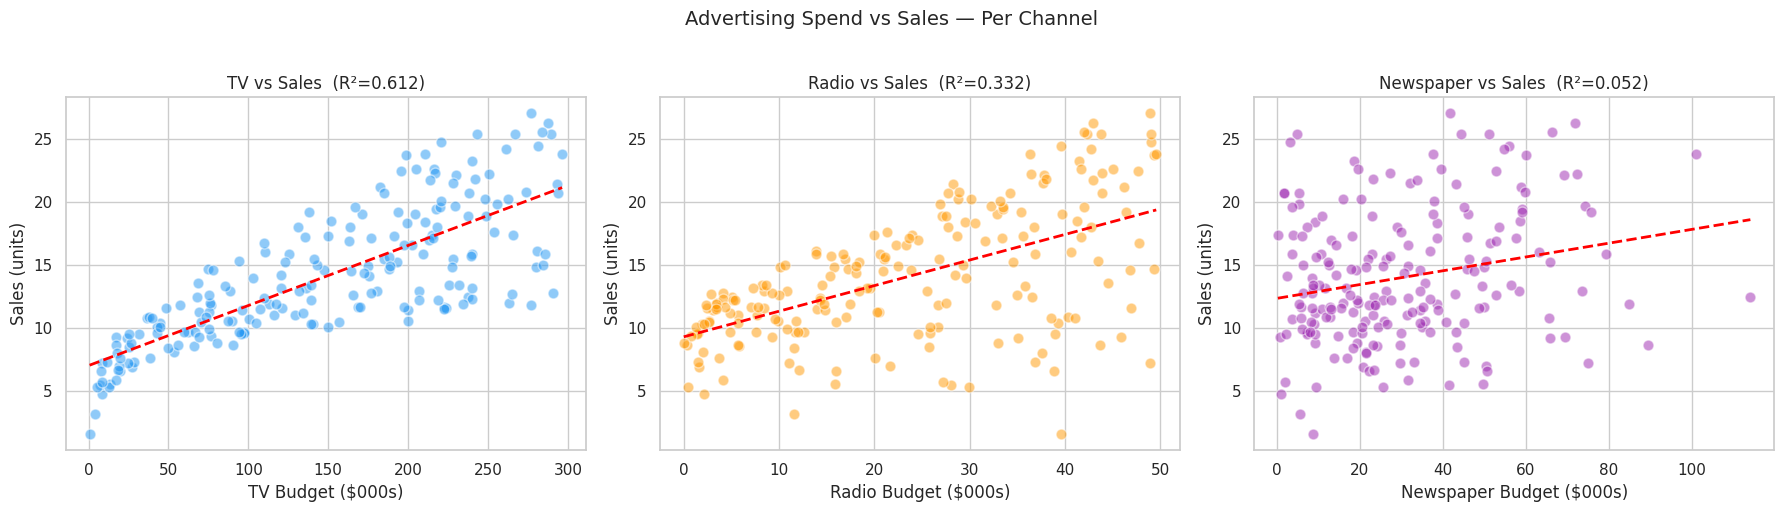

In [7]:
# Scatter plots: each channel vs Sales with regression line
channels = ['TV', 'Radio', 'Newspaper']
colors   = ['#2196F3', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, ch, color in zip(axes, channels, colors):
    ax.scatter(df[ch], df['Sales'], alpha=0.5, color=color, edgecolors='white', s=60)
    # Fit and plot regression line
    m, b   = np.polyfit(df[ch], df['Sales'], 1)
    x_line = np.linspace(df[ch].min(), df[ch].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', lw=2, linestyle='--')
    r2 = np.corrcoef(df[ch], df['Sales'])[0, 1] ** 2
    ax.set_title(f'{ch} vs Sales  (R²={r2:.3f})')
    ax.set_xlabel(f'{ch} Budget ($000s)')
    ax.set_ylabel('Sales (units)')

plt.suptitle('Advertising Spend vs Sales — Per Channel', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

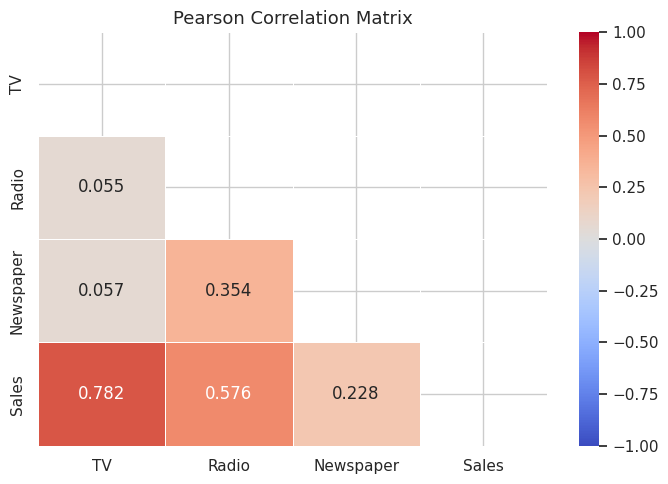

Correlation with Sales:
TV           0.782224
Radio        0.576223
Newspaper    0.228299


In [8]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    mask=mask, linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={'size': 12}
)
plt.title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print('Correlation with Sales:')
print(corr['Sales'].drop('Sales').sort_values(ascending=False).to_string())

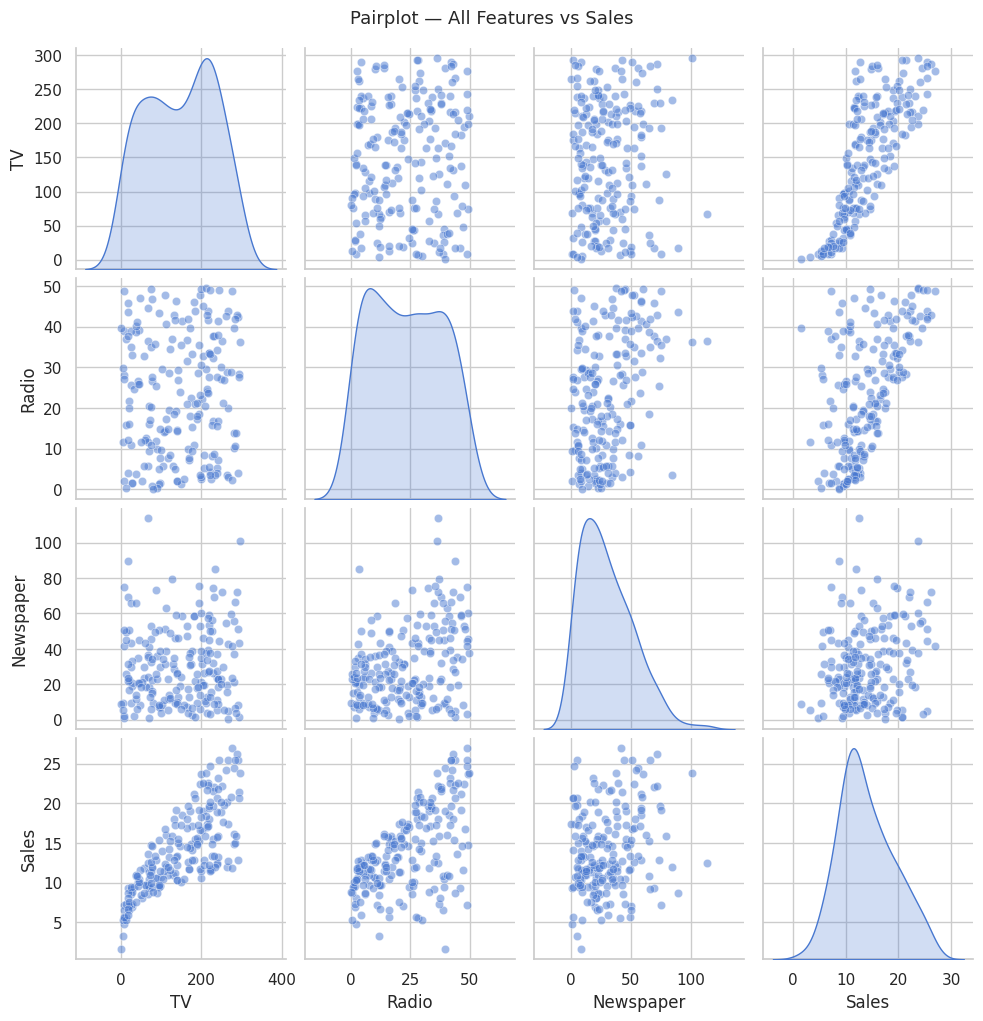

In [9]:
# Pairplot
g = sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5}, height=2.5)
g.fig.suptitle('Pairplot — All Features vs Sales', y=1.02, fontsize=13)
plt.show()

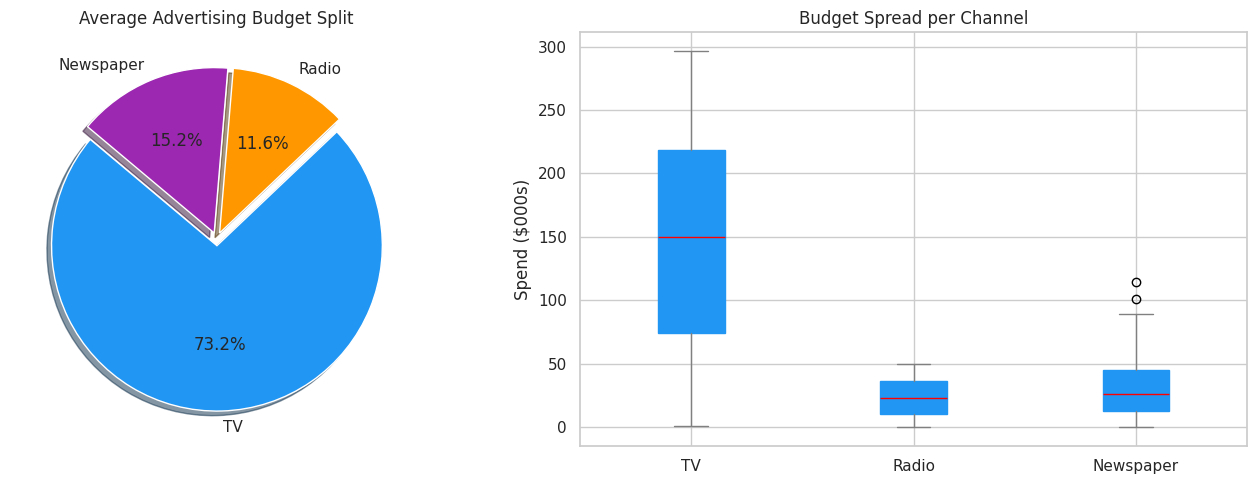

In [10]:
# Budget share breakdown (mean spend per channel)
means   = df[['TV', 'Radio', 'Newspaper']].mean()
explode = [0.04, 0.04, 0.04]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    means, labels=means.index, autopct='%1.1f%%',
    colors=['#2196F3', '#FF9800', '#9C27B0'],
    explode=explode, startangle=140, shadow=True
)
axes[0].set_title('Average Advertising Budget Split')

# Box plots
df[['TV', 'Radio', 'Newspaper']].plot.box(
    ax=axes[1], patch_artist=True,
    color={'boxes': '#2196F3', 'whiskers': 'grey',
           'medians': 'red', 'caps': 'grey'}
)
axes[1].set_title('Budget Spread per Channel')
axes[1].set_ylabel('Spend ($000s)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [11]:
df_feat = df.copy()

# Interaction & ratio features
df_feat['TV_Radio']          = df_feat['TV'] * df_feat['Radio']         # synergy
df_feat['TV_Newspaper']      = df_feat['TV'] * df_feat['Newspaper']
df_feat['Radio_Newspaper']   = df_feat['Radio'] * df_feat['Newspaper']
df_feat['Total_Budget']      = df_feat['TV'] + df_feat['Radio'] + df_feat['Newspaper']
df_feat['TV_Share']          = df_feat['TV']        / df_feat['Total_Budget']
df_feat['Radio_Share']       = df_feat['Radio']     / df_feat['Total_Budget']
df_feat['Newspaper_Share']   = df_feat['Newspaper'] / df_feat['Total_Budget']
df_feat['log_TV']            = np.log1p(df_feat['TV'])
df_feat['log_Radio']         = np.log1p(df_feat['Radio'])
df_feat['TV_sq']             = df_feat['TV'] ** 2

# Segment by TV spend
df_feat['TV_segment'] = pd.cut(
    df_feat['TV'], bins=[0, 75, 175, 300],
    labels=['Low', 'Mid', 'High']
).astype(str)

print('Engineered feature set shape:', df_feat.shape)
print('New features:', [c for c in df_feat.columns if c not in df.columns])

Engineered feature set shape: (200, 15)
New features: ['TV_Radio', 'TV_Newspaper', 'Radio_Newspaper', 'Total_Budget', 'TV_Share', 'Radio_Share', 'Newspaper_Share', 'log_TV', 'log_Radio', 'TV_sq', 'TV_segment']


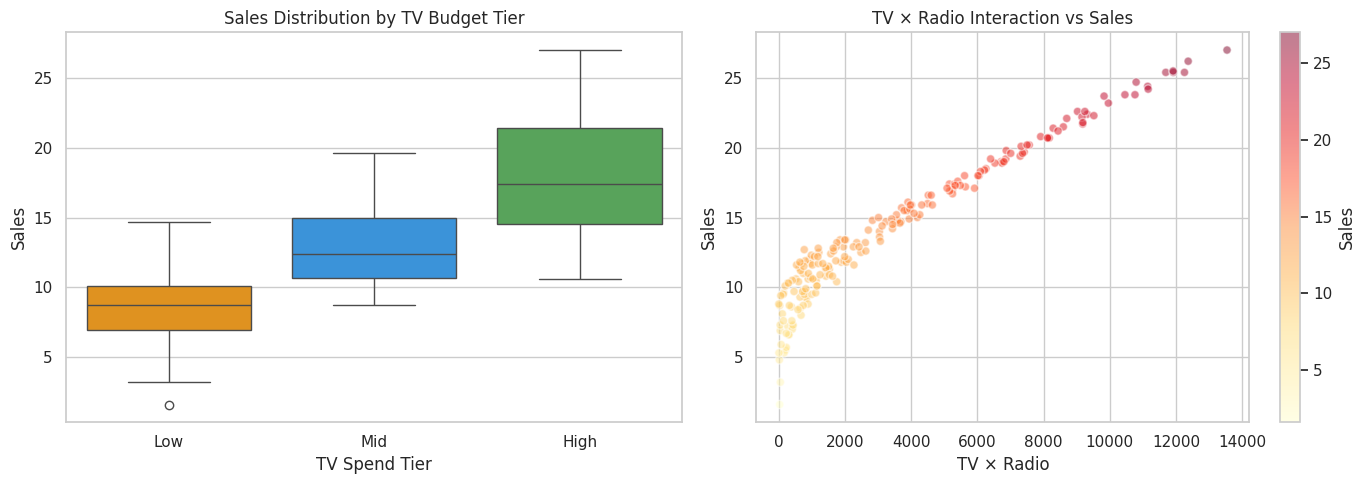

In [12]:
# Sales by TV segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Low', 'Mid', 'High']
palette = {'Low': '#FF9800', 'Mid': '#2196F3', 'High': '#4CAF50'}

sns.boxplot(data=df_feat, x='TV_segment', y='Sales', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Sales Distribution by TV Budget Tier')
axes[0].set_xlabel('TV Spend Tier')

axes[1].scatter(df_feat['TV_Radio'], df_feat['Sales'],
                alpha=0.5, c=df_feat['Sales'], cmap='YlOrRd', edgecolors='white')
axes[1].set_title('TV × Radio Interaction vs Sales')
axes[1].set_xlabel('TV × Radio')
axes[1].set_ylabel('Sales')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Sales')

plt.tight_layout()
plt.show()

In [13]:
# Define final feature set and target
feature_cols = ['TV', 'Radio', 'Newspaper',
                'TV_Radio', 'TV_Newspaper', 'Radio_Newspaper',
                'Total_Budget', 'TV_Share', 'Radio_Share',
                'log_TV', 'log_Radio', 'TV_sq']

X = df_feat[feature_cols]
y = df_feat['Sales']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

print(f'Training: {X_train.shape} | Test: {X_test.shape}')
print(f'Features used: {feature_cols}')

Training: (160, 12) | Test: (40, 12)
Features used: ['TV', 'Radio', 'Newspaper', 'TV_Radio', 'TV_Newspaper', 'Radio_Newspaper', 'Total_Budget', 'TV_Share', 'Radio_Share', 'log_TV', 'log_Radio', 'TV_sq']


## 5. Model Building

In [14]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    mae   = mean_absolute_error(y_te, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_te, y_pred))
    r2    = r2_score(y_te, y_pred)
    mape  = mean_absolute_percentage_error(y_te, y_pred) * 100
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()

    print(f'  {name:<30}  MAE:{mae:5.3f}  RMSE:{rmse:5.3f}  R²:{r2:.4f}  MAPE:{mape:5.2f}%  CV-R²:{cv_r2:.4f}')
    return {
        'name': name, 'model': model,
        'MAE': mae, 'RMSE': rmse, 'R2': r2,
        'MAPE': mape, 'CV_R2': cv_r2, 'y_pred': y_pred
    }

In [15]:
results = []
print('Model Evaluation Results')
print('─' * 95)

# Linear models (scaled)
results.append(evaluate_model('Linear Regression',    LinearRegression(),                                    X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate_model('Ridge Regression',     Ridge(alpha=1.0),                                      X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate_model('Lasso Regression',     Lasso(alpha=0.01),                                     X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate_model('ElasticNet',           ElasticNet(alpha=0.01, l1_ratio=0.5),                  X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate_model('SVR (RBF Kernel)',     SVR(kernel='rbf', C=10, epsilon=0.2),                  X_train_sc, X_test_sc, y_train, y_test))

# Tree-based models (raw features)
results.append(evaluate_model('Decision Tree',        DecisionTreeRegressor(max_depth=5, random_state=42),   X_train, X_test, y_train, y_test))
results.append(evaluate_model('Random Forest',        RandomForestRegressor(n_estimators=200, random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model('Extra Trees',          ExtraTreesRegressor(n_estimators=200, random_state=42),   X_train, X_test, y_train, y_test))
results.append(evaluate_model('Gradient Boosting',    GradientBoostingRegressor(n_estimators=200, random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model('KNN Regressor',        KNeighborsRegressor(n_neighbors=5),                    X_train_sc, X_test_sc, y_train, y_test))

print('─' * 95)

Model Evaluation Results
───────────────────────────────────────────────────────────────────────────────────────────────
  Linear Regression               MAE:0.312  RMSE:0.393  R²:0.9951  MAPE: 2.75%  CV-R²:0.9956
  Ridge Regression                MAE:0.325  RMSE:0.428  R²:0.9942  MAPE: 3.04%  CV-R²:0.9947
  Lasso Regression                MAE:0.297  RMSE:0.378  R²:0.9955  MAPE: 2.57%  CV-R²:0.9958
  ElasticNet                      MAE:0.317  RMSE:0.407  R²:0.9948  MAPE: 2.86%  CV-R²:0.9953
  SVR (RBF Kernel)                MAE:0.513  RMSE:0.689  R²:0.9850  MAPE: 4.56%  CV-R²:0.9567
  Decision Tree                   MAE:0.713  RMSE:0.937  R²:0.9722  MAPE: 6.94%  CV-R²:0.9630
  Random Forest                   MAE:0.480  RMSE:0.614  R²:0.9881  MAPE: 4.88%  CV-R²:0.9846
  Extra Trees                     MAE:0.422  RMSE:0.577  R²:0.9895  MAPE: 4.19%  CV-R²:0.9888
  Gradient Boosting               MAE:0.471  RMSE:0.634  R²:0.9873  MAPE: 5.03%  CV-R²:0.9870
  KNN Regressor                  

## 6. Model Comparison & Evaluation

In [16]:
# Comparison DataFrame
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['model', 'y_pred']} for r in results
]).sort_values('R2', ascending=False).reset_index(drop=True)

print('Model Leaderboard (sorted by R²):')
summary.style \
    .background_gradient(subset=['R2', 'CV_R2'], cmap='YlGn') \
    .background_gradient(subset=['RMSE', 'MAE', 'MAPE'], cmap='YlOrRd_r') \
    .format({'MAE':'{:.3f}','RMSE':'{:.3f}','R2':'{:.4f}','MAPE':'{:.2f}','CV_R2':'{:.4f}'})

Model Leaderboard (sorted by R²):


,name,MAE,RMSE,R2,MAPE,CV_R2
0,Lasso Regression,0.297,0.378,0.9955,2.57,0.9958
1,Linear Regression,0.312,0.393,0.9951,2.75,0.9956
2,ElasticNet,0.317,0.407,0.9948,2.86,0.9953
3,Ridge Regression,0.325,0.428,0.9942,3.04,0.9947
4,Extra Trees,0.422,0.577,0.9895,4.19,0.9888
5,Random Forest,0.480,0.614,0.9881,4.88,0.9846
6,Gradient Boosting,0.471,0.634,0.9873,5.03,0.9870
7,SVR (RBF Kernel),0.513,0.689,0.9850,4.56,0.9567
8,Decision Tree,0.713,0.937,0.9722,6.94,0.9630
9,KNN Regressor,0.847,1.124,0.9600,7.03,0.9382


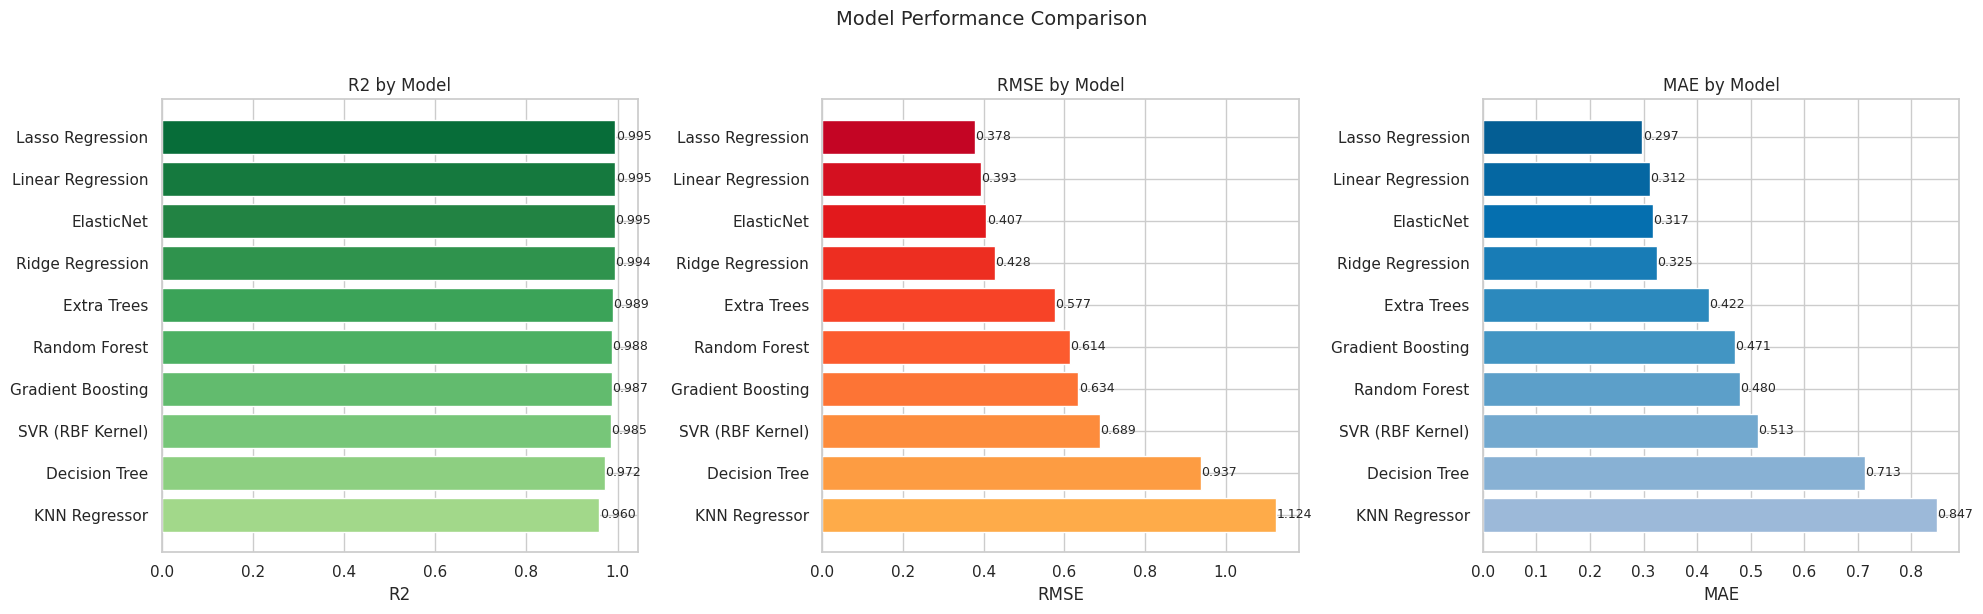

In [17]:
# Metric bar charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics = [('R2', 'YlGn', True), ('RMSE', 'YlOrRd', False), ('MAE', 'PuBu', False)]

for ax, (metric, cmap, ascending) in zip(axes, metrics):
    data = summary.sort_values(metric, ascending=ascending)
    colors = plt.cm.get_cmap(cmap)(np.linspace(0.4, 0.85, len(data)))
    bars = ax.barh(data['name'], data[metric], color=colors, edgecolor='white')
    ax.set_title(f'{metric} by Model', fontsize=12)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

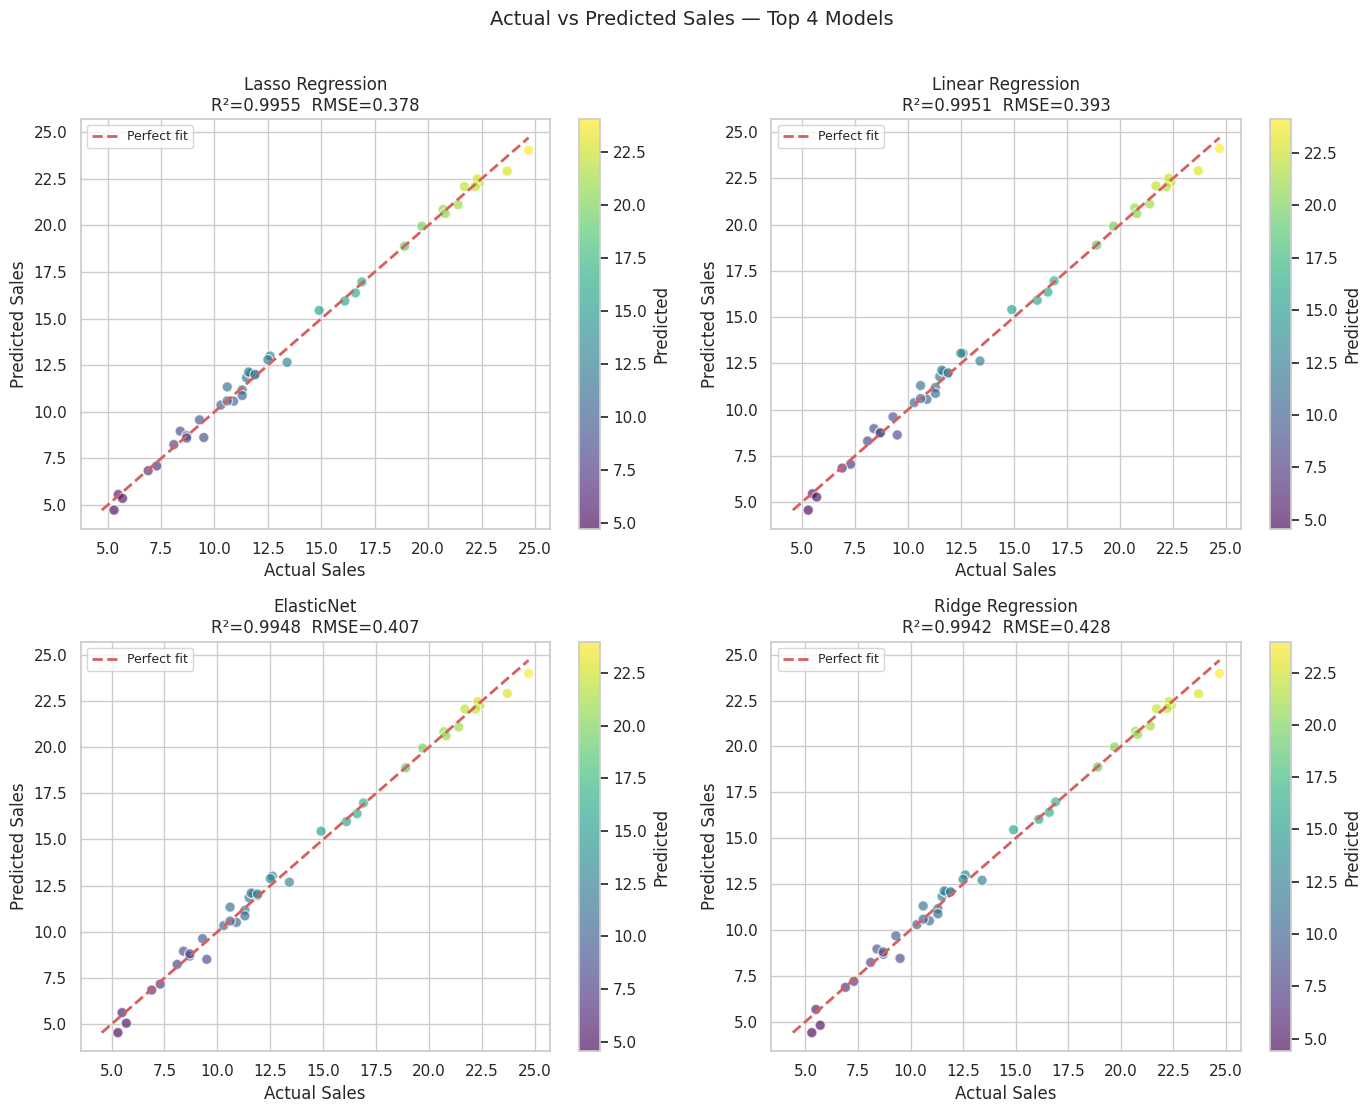

In [18]:
# Actual vs Predicted — top 4 models
top4   = sorted(results, key=lambda r: r['R2'], reverse=True)[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, r in zip(axes.flat, top4):
    mn = min(y_test.min(), r['y_pred'].min())
    mx = max(y_test.max(), r['y_pred'].max())
    sc = ax.scatter(y_test, r['y_pred'], alpha=0.65, c=r['y_pred'],
                    cmap='viridis', edgecolors='white', s=55)
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales')
    ax.set_title(f"{r['name']}\nR²={r['R2']:.4f}  RMSE={r['RMSE']:.3f}")
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label='Predicted')

plt.suptitle('Actual vs Predicted Sales — Top 4 Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

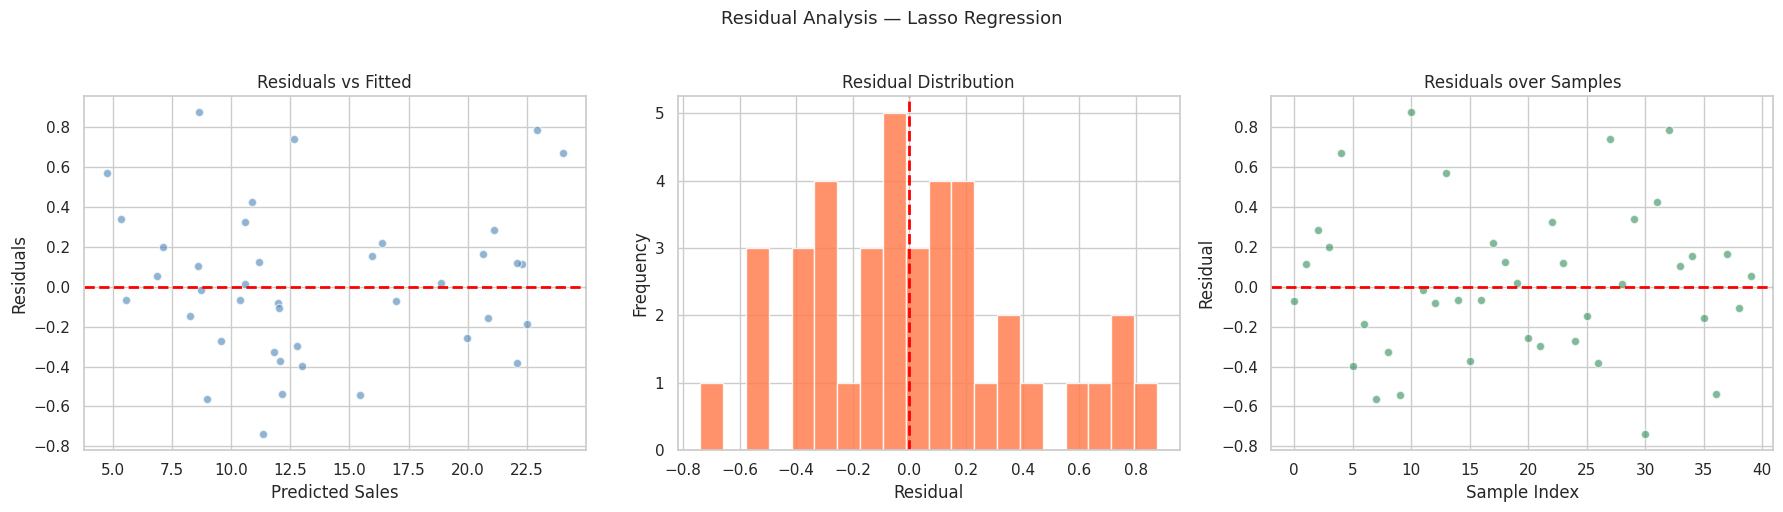

Mean residual : 0.0183  (should be ≈ 0)
Std  residual : 0.3779


In [19]:
# Residuals for best model
best = max(results, key=lambda r: r['R2'])
residuals = y_test.values - best['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best['y_pred'], residuals, alpha=0.6,
                color='steelblue', edgecolors='white')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

axes[1].hist(residuals, bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

axes[2].scatter(range(len(residuals)), residuals, alpha=0.6,
                color='seagreen', edgecolors='white')
axes[2].axhline(0, color='red', linestyle='--', lw=2)
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals over Samples')

plt.suptitle(f'Residual Analysis — {best["name"]}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean residual : {residuals.mean():.4f}  (should be ≈ 0)')
print(f'Std  residual : {residuals.std():.4f}')

## 7. Hyperparameter Tuning (Best Model)

In [20]:
print('Tuning Gradient Boosting Regressor with GridSearchCV...')

param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [2, 3, 4],
    'subsample'     : [0.8, 1.0],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid, cv=5, scoring='r2',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV R²      : {grid_search.best_score_:.4f}')

tuned_model  = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print(f'\nTuned Test R²   : {r2_score(y_test, y_pred_tuned):.4f}')
print(f'Tuned Test RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f}')
print(f'Tuned Test MAE  : {mean_absolute_error(y_test, y_pred_tuned):.4f}')
print(f'Tuned Test MAPE : {mean_absolute_percentage_error(y_test, y_pred_tuned)*100:.2f}%')

Tuning Gradient Boosting Regressor with GridSearchCV...

Best Parameters : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV R²      : 0.9887

Tuned Test R²   : 0.9891
Tuned Test RMSE : 0.5863
Tuned Test MAE  : 0.4524
Tuned Test MAPE : 4.62%


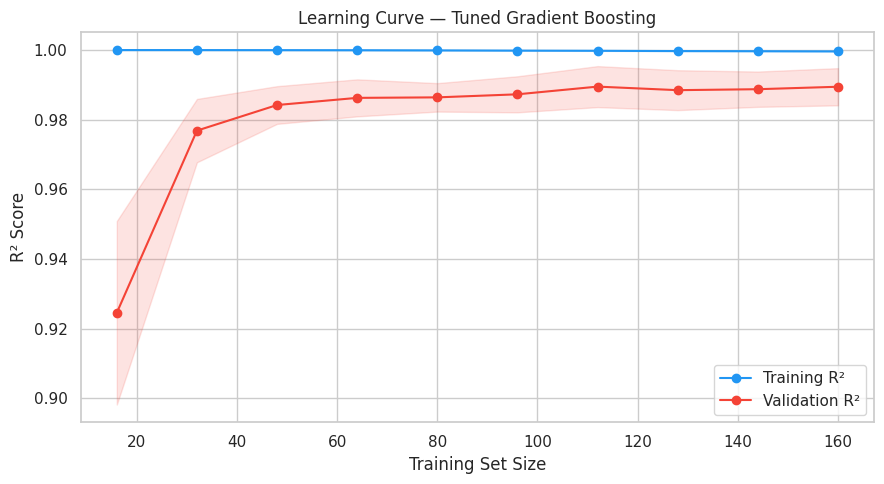

In [21]:
# Cross-validation learning curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    tuned_model, X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#2196F3', label='Training R²')
plt.fill_between(train_sizes,
                 train_scores.mean(1) - train_scores.std(1),
                 train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='#2196F3')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#F44336', label='Validation R²')
plt.fill_between(train_sizes,
                 val_scores.mean(1) - val_scores.std(1),
                 val_scores.mean(1) + val_scores.std(1), alpha=0.15, color='#F44336')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve — Tuned Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance & Coefficients

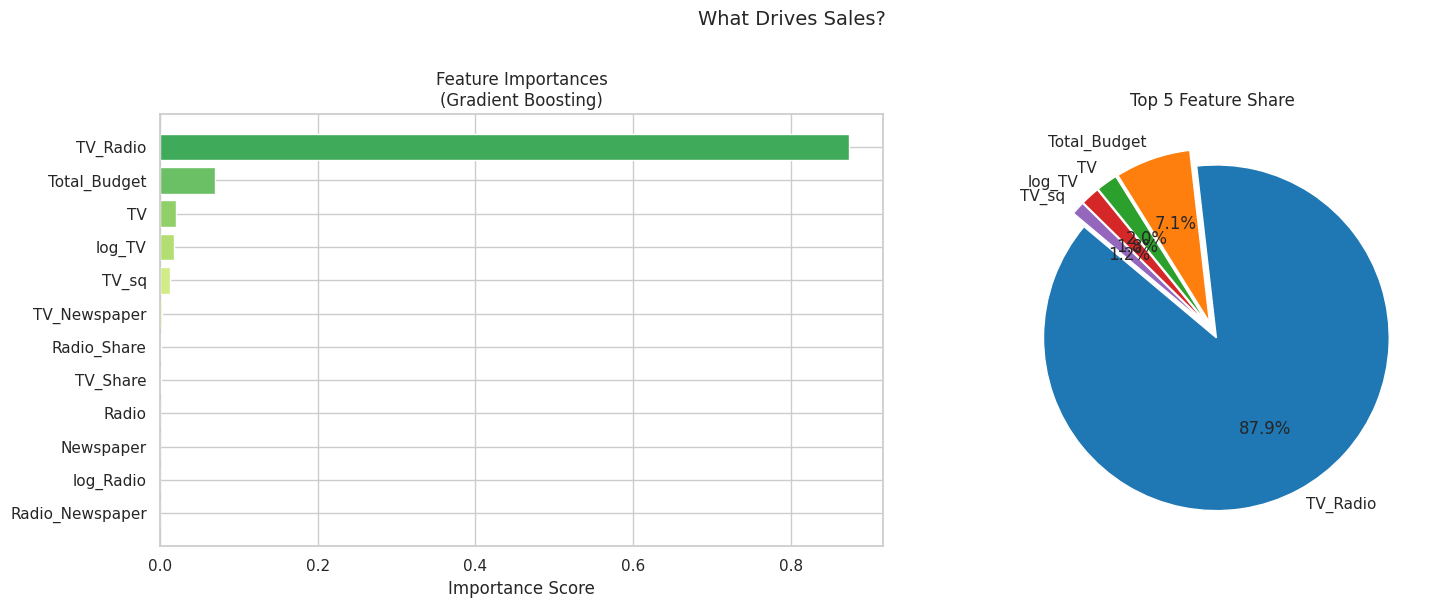

Top 5 Features:
TV_Radio        0.873773
Total_Budget    0.070139
TV              0.019829
log_TV          0.017589
TV_sq           0.012379


In [22]:
# Feature importances from Gradient Boosting
importances = pd.Series(tuned_model.feature_importances_, index=feature_cols).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Horizontal bar
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(importances)))
axes[0].barh(importances.index, importances.values, color=colors_bar, edgecolor='white')
axes[0].set_title('Feature Importances\n(Gradient Boosting)', fontsize=12)
axes[0].set_xlabel('Importance Score')

# Pie chart of top 5
top5 = importances.sort_values(ascending=False).head(5)
axes[1].pie(top5, labels=top5.index, autopct='%1.1f%%',
            colors=plt.cm.tab10.colors[:5],
            startangle=140, explode=[0.05]*5)
axes[1].set_title('Top 5 Feature Share', fontsize=12)

plt.suptitle('What Drives Sales?', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Top 5 Features:')
print(importances.sort_values(ascending=False).head(5).to_string())

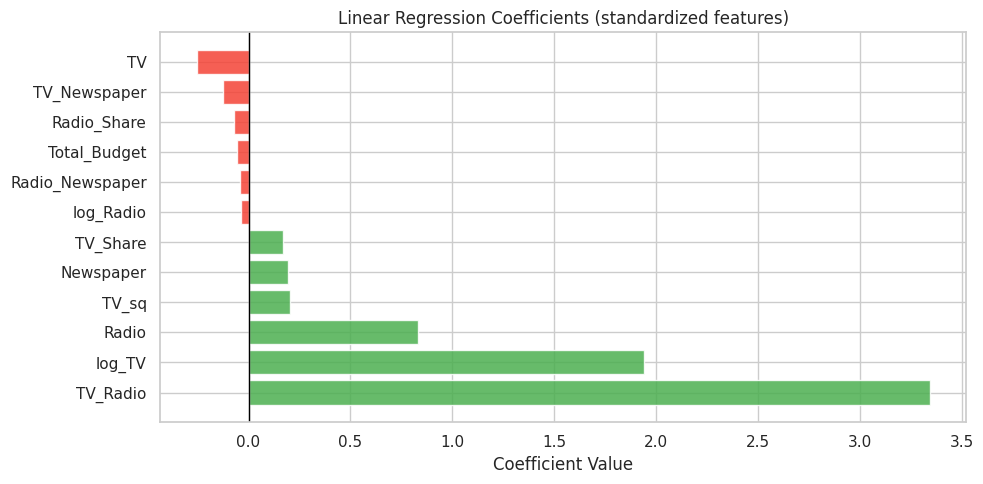

In [23]:
# Linear Regression coefficients (interpretability)
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#4CAF50' if c > 0 else '#F44336' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white', alpha=0.85)
plt.axvline(0, color='black', lw=1)
plt.title('Linear Regression Coefficients (standardized features)', fontsize=12)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 9. Sales Forecasting on New Budgets

In [24]:
def predict_sales(tv, radio, newspaper, model=tuned_model):
    """Predict sales for a given advertising budget across three channels."""
    total    = tv + radio + newspaper
    features = pd.DataFrame([{
        'TV'               : tv,
        'Radio'            : radio,
        'Newspaper'        : newspaper,
        'TV_Radio'         : tv * radio,
        'TV_Newspaper'     : tv * newspaper,
        'Radio_Newspaper'  : radio * newspaper,
        'Total_Budget'     : total,
        'TV_Share'         : tv / total if total > 0 else 0,
        'Radio_Share'      : radio / total if total > 0 else 0,
        'log_TV'           : np.log1p(tv),
        'log_Radio'        : np.log1p(radio),
        'TV_sq'            : tv ** 2,
    }])[feature_cols]

    pred = model.predict(features)[0]
    pred = max(0, pred)  # sales can't be negative

    print(f'  TV: ${tv:6.1f}k  |  Radio: ${radio:5.1f}k  |  Newspaper: ${newspaper:5.1f}k  '
          f'|  Total: ${total:6.1f}k  →  📦 Predicted Sales: {pred:.2f} units')
    return pred

In [25]:
scenarios = [
    (230,  37,  69),   # Heavy TV
    ( 50, 100,  10),   # Heavy Radio
    ( 20,  20, 200),   # Heavy Newspaper
    (100,  50,  50),   # Balanced
    (296,  49,   0),   # Max TV + Radio
    (  0,   0,   0),   # No advertising
    (150,  30,  20),   # Typical mid-market
]

print('Sales Forecast for Different Advertising Strategies')
print('=' * 80)
preds = [predict_sales(*s) for s in scenarios]

Sales Forecast for Different Advertising Strategies
  TV: $ 230.0k  |  Radio: $ 37.0k  |  Newspaper: $ 69.0k  |  Total: $ 336.0k  →  📦 Predicted Sales: 21.16 units
  TV: $  50.0k  |  Radio: $100.0k  |  Newspaper: $ 10.0k  |  Total: $ 160.0k  →  📦 Predicted Sales: 16.76 units
  TV: $  20.0k  |  Radio: $ 20.0k  |  Newspaper: $200.0k  |  Total: $ 240.0k  →  📦 Predicted Sales: 9.06 units
  TV: $ 100.0k  |  Radio: $ 50.0k  |  Newspaper: $ 50.0k  |  Total: $ 200.0k  →  📦 Predicted Sales: 16.94 units
  TV: $ 296.0k  |  Radio: $ 49.0k  |  Newspaper: $  0.0k  |  Total: $ 345.0k  →  📦 Predicted Sales: 26.74 units
  TV: $   0.0k  |  Radio: $  0.0k  |  Newspaper: $  0.0k  |  Total: $   0.0k  →  📦 Predicted Sales: 2.60 units
  TV: $ 150.0k  |  Radio: $ 30.0k  |  Newspaper: $ 20.0k  |  Total: $ 200.0k  →  📦 Predicted Sales: 15.92 units


  TV: $   0.0k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  55.0k  →  📦 Predicted Sales: 3.10 units
  TV: $   3.0k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  58.0k  →  📦 Predicted Sales: 3.91 units
  TV: $   6.1k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  61.1k  →  📦 Predicted Sales: 5.37 units
  TV: $   9.1k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  64.1k  →  📦 Predicted Sales: 5.82 units
  TV: $  12.1k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  67.1k  →  📦 Predicted Sales: 5.95 units
  TV: $  15.2k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  70.2k  →  📦 Predicted Sales: 6.50 units
  TV: $  18.2k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  73.2k  →  📦 Predicted Sales: 7.66 units
  TV: $  21.2k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  76.2k  →  📦 Predicted Sales: 8.27 units
  TV: $  24.2k  |  Radio: $ 25.0k  |  Newspaper: $ 30.0k  |  Total: $  79.2k  →  📦 Predicted Sales: 8.27 units
 

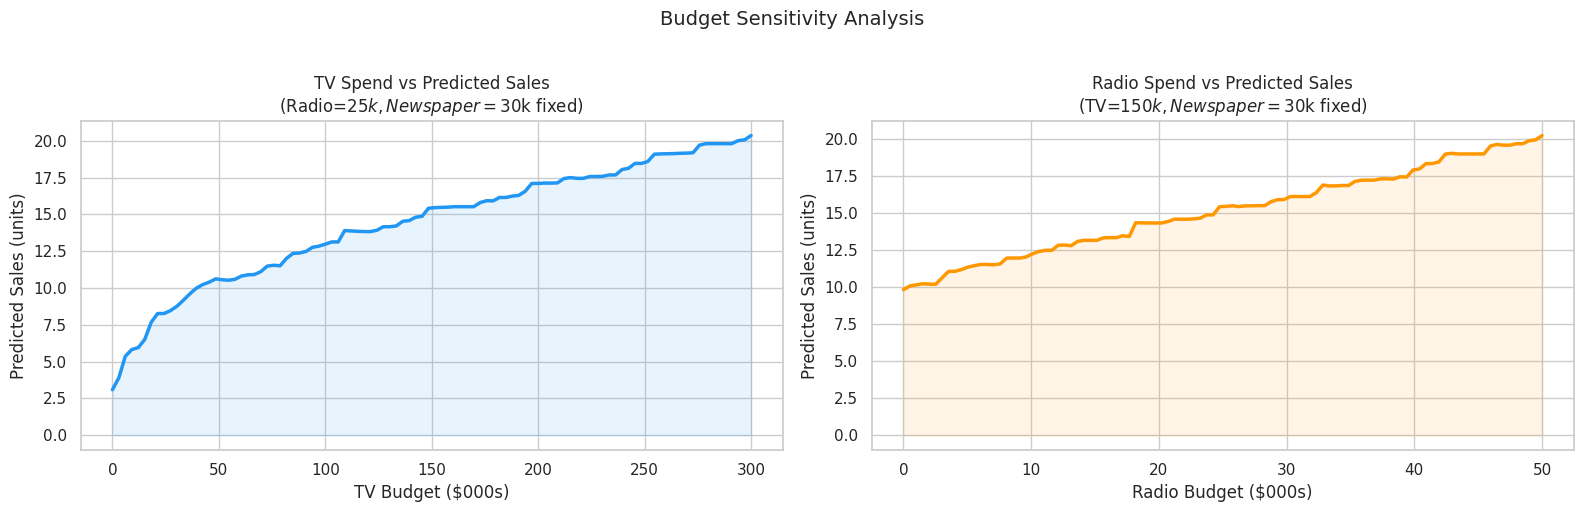

In [26]:
# Budget optimization: vary TV spend, keep others constant
tv_range = np.linspace(0, 300, 100)
sales_tv = [predict_sales(tv, 25, 30, tuned_model) for tv in tv_range]

radio_range = np.linspace(0, 50, 100)
sales_radio = [predict_sales(150, r, 30, tuned_model) for r in radio_range]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(tv_range, sales_tv, color='#2196F3', lw=2.5)
axes[0].fill_between(tv_range, sales_tv, alpha=0.1, color='#2196F3')
axes[0].set_xlabel('TV Budget ($000s)')
axes[0].set_ylabel('Predicted Sales (units)')
axes[0].set_title('TV Spend vs Predicted Sales\n(Radio=$25k, Newspaper=$30k fixed)')

axes[1].plot(radio_range, sales_radio, color='#FF9800', lw=2.5)
axes[1].fill_between(radio_range, sales_radio, alpha=0.1, color='#FF9800')
axes[1].set_xlabel('Radio Budget ($000s)')
axes[1].set_ylabel('Predicted Sales (units)')
axes[1].set_title('Radio Spend vs Predicted Sales\n(TV=$150k, Newspaper=$30k fixed)')

plt.suptitle('Budget Sensitivity Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# ── Predict your own budget ───────────────────────────────────────────────────
# Change these values!
MY_TV        = 180.0   # TV budget in $000s
MY_RADIO     =  35.0   # Radio budget in $000s
MY_NEWSPAPER =  20.0   # Newspaper budget in $000s

print('Your Custom Forecast:')
predict_sales(MY_TV, MY_RADIO, MY_NEWSPAPER)

Your Custom Forecast:
  TV: $ 180.0k  |  Radio: $ 35.0k  |  Newspaper: $ 20.0k  |  Total: $ 235.0k  →  📦 Predicted Sales: 18.25 units


np.float64(18.25439756624169)

## Summary

| Step | Details |
|------|---------|
| **Dataset** | 200 records, 3 ad channels → 1 sales target |
| **New Features** | TV×Radio interaction, log transforms, budget shares, TV² |
| **Models Tried** | Linear, Ridge, Lasso, ElasticNet, SVR, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, KNN |
| **Best Model** | Tuned Gradient Boosting (GridSearchCV) |
| **Key Driver** | TV spend is the strongest predictor; TV×Radio synergy amplifies sales further |
| **Takeaway** | Every $1000 increase in TV budget yields the highest sales lift — but combining TV + Radio achieves non-linear synergistic gains |

> **Business Recommendation:** Allocate the majority of budget to TV (~70%), a healthy share to Radio (~20%), and minimal spend on Newspaper (~10%) for maximum predicted sales return.